# **RNN Model Training on IMDB Dataset**

In [1]:
import warnings 
warnings.filterwarnings('ignore')

In [2]:
import keras
from keras import layers, Sequential
from keras.layers import Dense, SimpleRNN, Embedding, Flatten

2026-06-18 16:38:42.545952: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781800722.743010      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781800722.801445      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781800723.305923      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781800723.305965      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781800723.305967      58 computation_placer.cc:177] computation placer alr

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data()

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [4]:
print(x_train.shape)
print(x_test.shape)

(25000,)
(25000,)


In [5]:
import numpy as np

In [6]:
np.unique(y_train)

array([0, 1])

In [7]:
x_train       # each number in the first paragraph of numbers represents words in the first paragraph


array([list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 22665, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 21631, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 19193, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 10311, 8, 4, 107, 117, 5952, 15, 256, 4, 31050, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 12118, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]),
       list([1, 194, 1

Since padding is not applied on the IMDB data we will be applying Padding on it

In [8]:
from keras.utils import pad_sequences

In [9]:
x_train = pad_sequences(x_train, padding='post')       # adds padding to the end of the sentence
x_test = pad_sequences(x_test, padding='post')

In [11]:
print(x_train.shape)
print()
print(x_train)
print()
print(x_train[0])

(25000, 2494)

[[   1   14   22 ...    0    0    0]
 [   1  194 1153 ...    0    0    0]
 [   1   14   47 ...    0    0    0]
 ...
 [   1   11    6 ...    0    0    0]
 [   1 1446 7079 ...    0    0    0]
 [   1   17    6 ...    0    0    0]]

[ 1 14 22 ...  0  0  0]


In [12]:
model = Sequential([
    layers.SimpleRNN(32, input_shape=(50,1), return_sequences=False),
    layers.Dense(1, activation='sigmoid')
])

I0000 00:00:1781800859.102549      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781800859.108651      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


1. `return_sequences=False` (Default)
The RNN processes all 50 time steps, but only returns the final output vector from the very last step.

- Output Shape: (batch_size, 32)
- Use Case: Used when connecting the recurrent layer directly to a final classifier layer like Dense, which expects a single output vector per review.

2. `return_sequences=True`
The RNN returns the output vector for every single one of the 50 time steps.

- Output Shape: (batch_size, 50, 32)
- Use Case: Used when you want to stack multiple recurrent layers on top of each other, since the next RNN layer expects a 3D sequence as input.

In [15]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 106s 134ms/step - accuracy: 0.5010 - loss: 0.6937 - val_accuracy: 0.5000 - val_loss: 0.6944
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 102s 131ms/step - accuracy: 0.5022 - loss: 0.6940 - val_accuracy: 0.5020 - val_loss: 0.6936
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 102s 130ms/step - accuracy: 0.4990 - loss: 0.6939 - val_accuracy: 0.4967 - val_loss: 0.6941
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 102s 131ms/step - accuracy: 0.5038 - loss: 0.6938 - val_accuracy: 0.5029 - val_loss: 0.6966
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 102s 131ms/step - accuracy: 0.5026 - loss: 0.6939 - val_accuracy: 0.5034 - val_loss: 0.6933


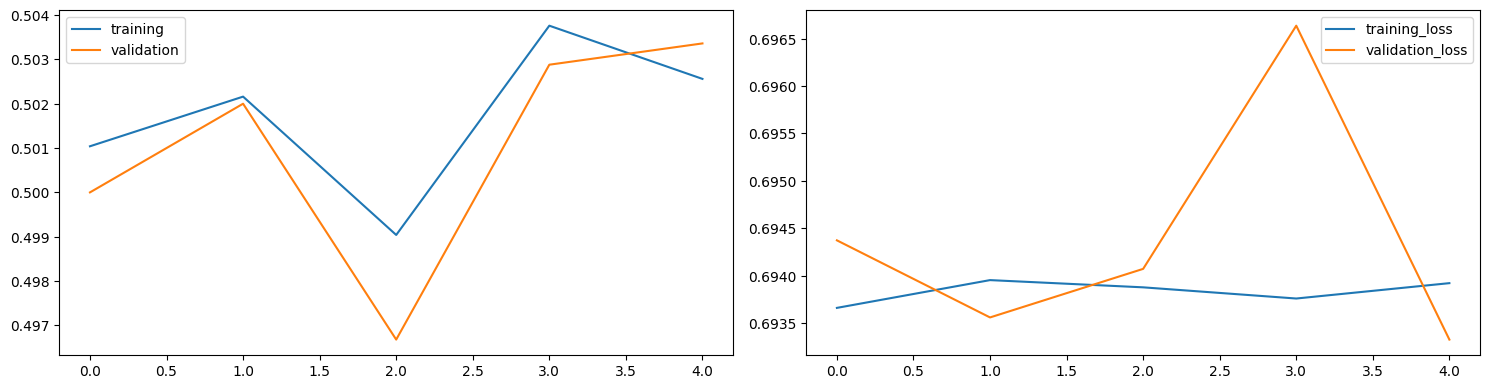

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='training')
plt.plot(history.history['val_accuracy'], label='validation')
plt.legend()


plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='training_loss')
plt.plot(history.history['val_loss'], label='validation_loss')
plt.legend()

plt.tight_layout()
plt.show()